In [1]:
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error, mean_squared_error

### 9. Avaliação dos Modelos

In [2]:
# Carregando o modelo Gradient Boosting
model_gb = joblib.load('model_gb_v1.joblib')

In [3]:
type(model_gb)

sklearn.pipeline.Pipeline

In [4]:
# Carregando o modelo KNN
model_knn = joblib.load('model_knn_v1.joblib')

In [5]:
type(model_knn)

sklearn.pipeline.Pipeline

In [6]:
# Carregando o modelo SVR Linear
model_svr = joblib.load('model_svr_v1.joblib')

In [7]:
type(model_svr)

sklearn.pipeline.Pipeline

In [8]:
# Carregando o Dataset pré processado
df_limpo = pd.read_csv('Housing_pre_processing.csv')

In [9]:
# Dados de treino e teste
X = df_limpo.drop(columns=['preco'])
y = df_limpo['preco']

In [10]:
# Dividindo os dados
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.20, random_state=42)

In [11]:
def real_formatter(x, pos):
    return f'R$ {x:,.2f}'.replace(',', 'X').replace('.', ',').replace('X', '.')

### Gradient Bosting

In [12]:
predictions_gb = model_gb.predict(X_teste) # Realizando as predições

In [13]:
# Coeficiente de determinação
r2_gb = r2_score(y_teste, predictions_gb)
print(f'Coeficiente de determinação de: {r2_gb * 100:.2f}%')

Coeficiente de determinação de: 57.86%


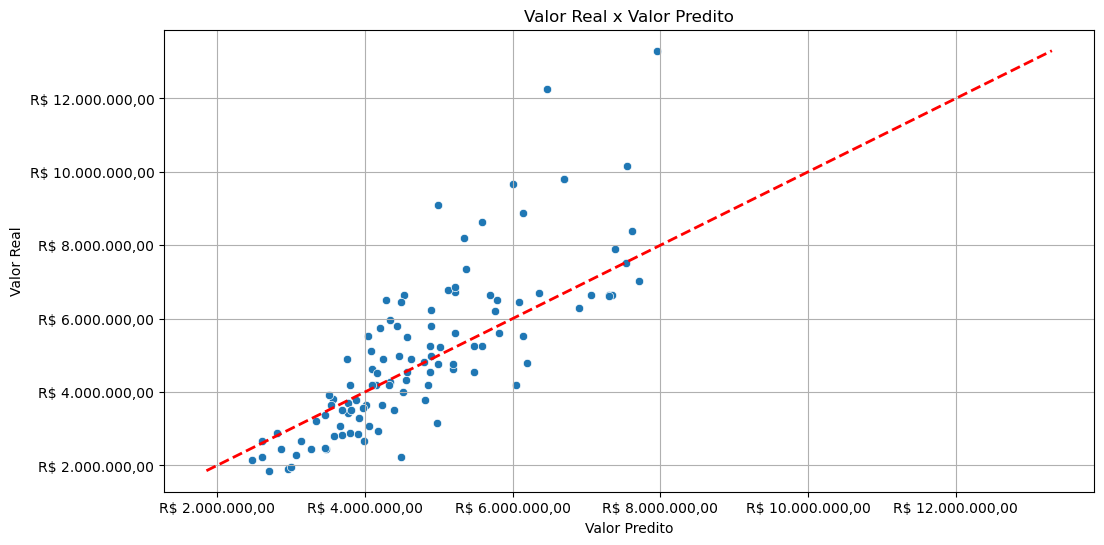

In [14]:
plt.figure(figsize=(12,6))
sns.scatterplot(x=predictions_gb, y=y_teste)
plt.ylabel('Valor Real')
plt.xlabel('Valor Predito')
plt.plot(
    [y_teste.min(), y_teste.max()],
    [y_teste.min(), y_teste.max()], 'r--', lw=2)
plt.grid(True)
ax = plt.gca()
ax.xaxis.set_major_formatter(FuncFormatter(real_formatter))
ax.yaxis.set_major_formatter(FuncFormatter(real_formatter))
plt.title('Valor Real x Valor Predito')
plt.show()

In [15]:
# Métricas 
mae_gb = mean_absolute_error(y_teste, predictions_gb)
rmse_gb = root_mean_squared_error(y_teste, predictions_gb)

print(f'MAE: {mae_gb:.2f}'.replace(',', 'X').replace('.', ',').replace('X', '.'))
print(f'RMSE: {rmse_gb:.2f}'.replace(',', 'X').replace('.', ',').replace('X', '.'))

MAE: 984148,84
RMSE: 1436560,59


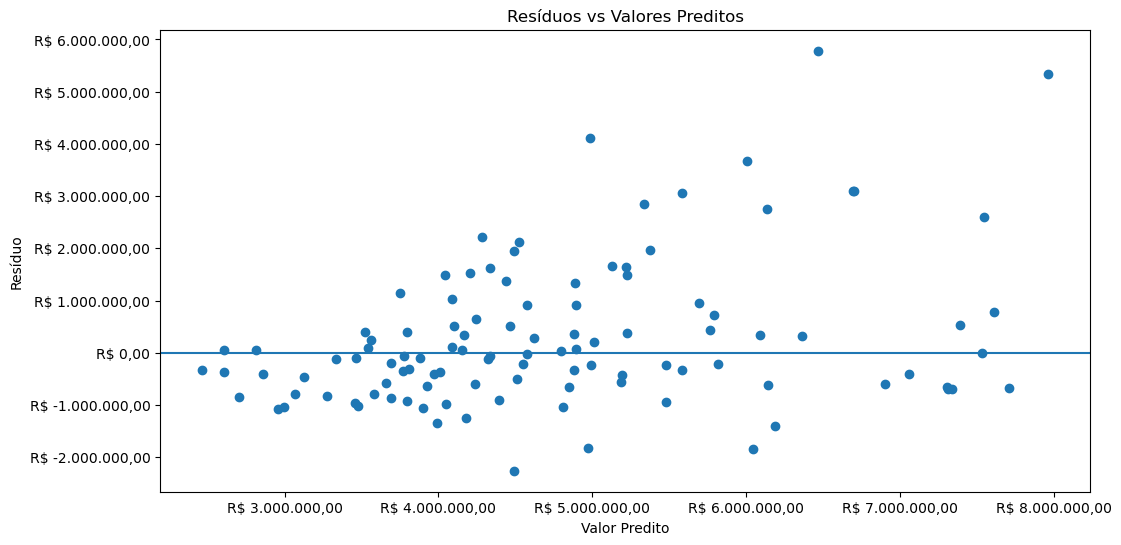

In [16]:
residuos_gb = y_teste - predictions_gb

plt.figure(figsize=(12,6))
plt.scatter(predictions_gb, residuos_gb)
plt.axhline(0)

plt.xlabel('Valor Predito')
plt.ylabel('Resíduo')

ax = plt.gca()
ax.xaxis.set_major_formatter(FuncFormatter(real_formatter))
ax.yaxis.set_major_formatter(FuncFormatter(real_formatter))

plt.title('Resíduos vs Valores Preditos')
plt.show()

### KNN

In [17]:
predictions_knn = model_knn.predict(X_teste) # Realizando as predições

In [18]:
# Coeficiente de determinação
r2_knn = r2_score(y_teste, predictions_knn)
print(f'Coeficiente de determinação de: {r2_knn * 100:.2f}%')

Coeficiente de determinação de: 53.60%


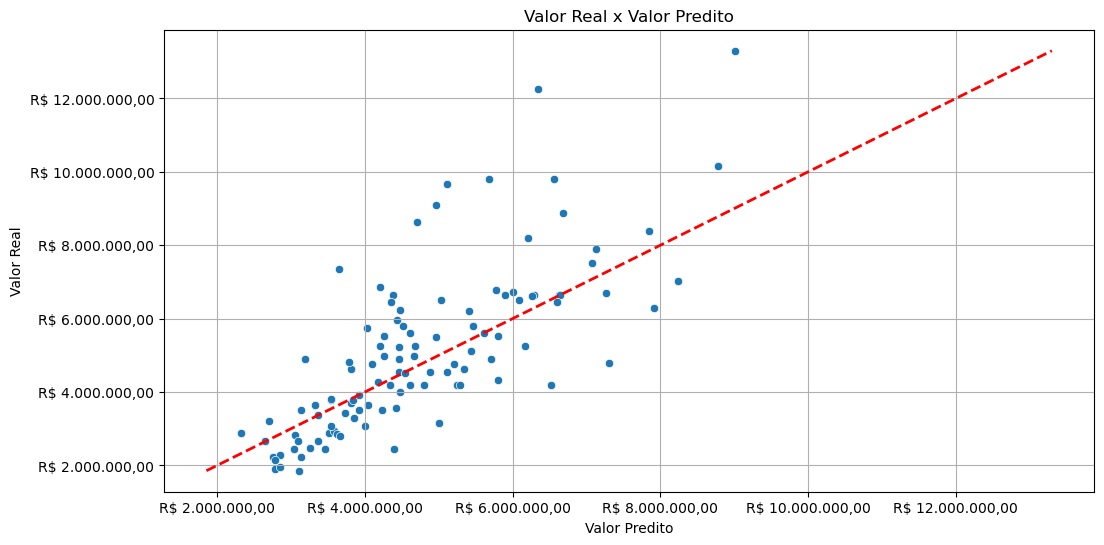

In [19]:
plt.figure(figsize=(12,6))
sns.scatterplot(x=predictions_knn, y=y_teste)
plt.ylabel('Valor Real')
plt.xlabel('Valor Predito')
plt.plot(
    [y_teste.min(), y_teste.max()],
    [y_teste.min(), y_teste.max()], 'r--', lw=2)
plt.grid(True)
ax = plt.gca()
ax.xaxis.set_major_formatter(FuncFormatter(real_formatter))
ax.yaxis.set_major_formatter(FuncFormatter(real_formatter))
plt.title('Valor Real x Valor Predito')
plt.show()

In [20]:
# Métricas 
mae_knn = mean_absolute_error(y_teste, predictions_knn)
rmse_knn = root_mean_squared_error(y_teste, predictions_knn)

print(f'MAE: {mae_knn:.2f}'.replace(',', 'X').replace('.', ',').replace('X', '.'))
print(f'RMSE: {rmse_knn:.2f}'.replace(',', 'X').replace('.', ',').replace('X', '.'))

MAE: 1039768,83
RMSE: 1507414,16


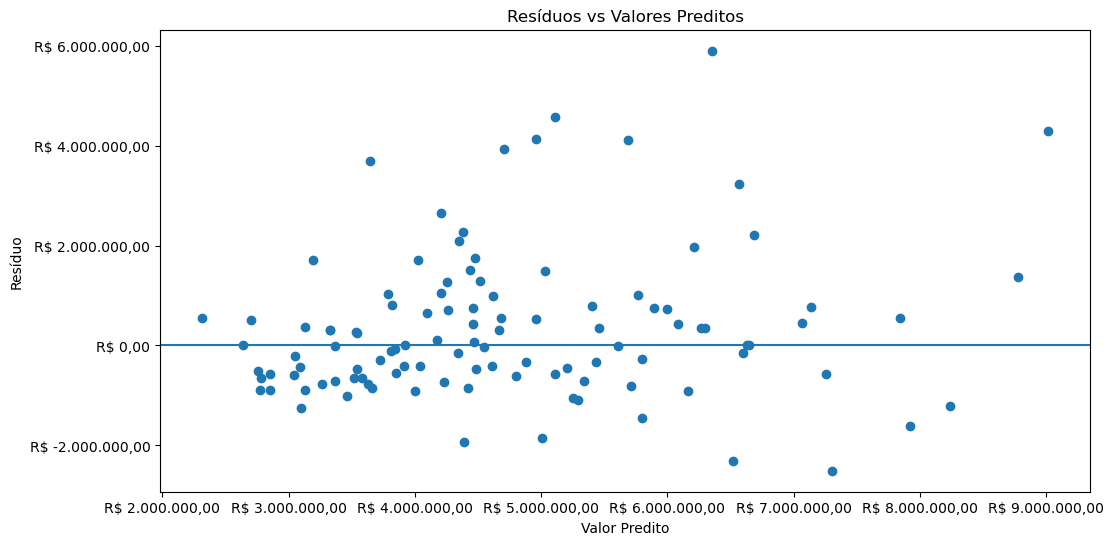

In [21]:
residuos_knn = y_teste - predictions_knn

plt.figure(figsize=(12,6))
plt.scatter(predictions_knn, residuos_knn)
plt.axhline(0)

plt.xlabel('Valor Predito')
plt.ylabel('Resíduo')

ax = plt.gca()
ax.xaxis.set_major_formatter(FuncFormatter(real_formatter))
ax.yaxis.set_major_formatter(FuncFormatter(real_formatter))

plt.title('Resíduos vs Valores Preditos')
plt.show()

### SVR Linear

In [22]:
predictions_svr = model_svr.predict(X_teste) # Realizando as predições

In [23]:
# Coeficiente de determinação
r2_svr = r2_score(y_teste, predictions_svr)
print(f'Coeficiente de determinação de: {r2_svr * 100:.2f}%')

Coeficiente de determinação de: 64.20%


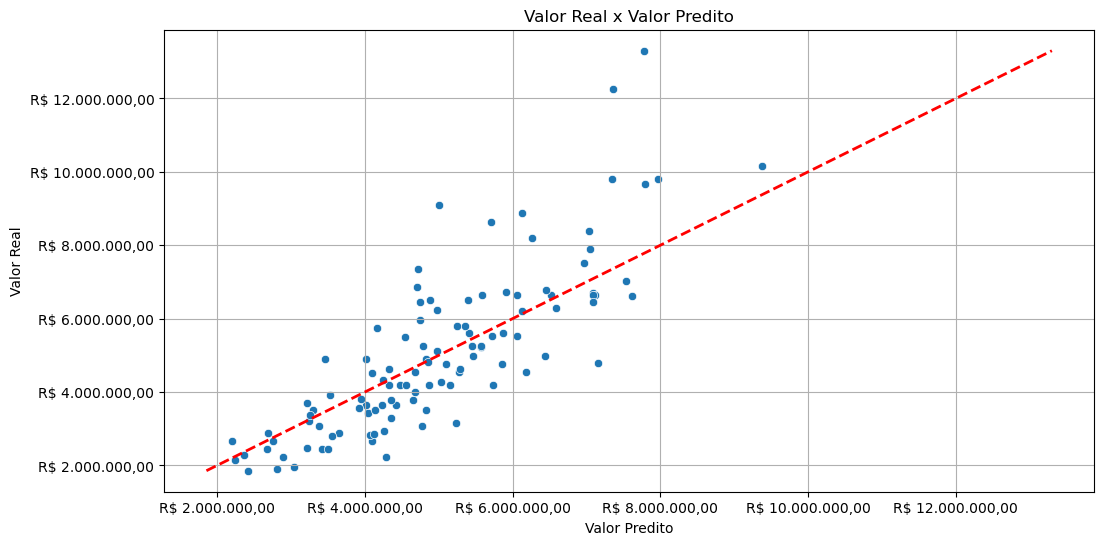

In [24]:
plt.figure(figsize=(12,6))
sns.scatterplot(x=predictions_svr, y=y_teste)
plt.ylabel('Valor Real')
plt.xlabel('Valor Predito')
plt.plot(
    [y_teste.min(), y_teste.max()],
    [y_teste.min(), y_teste.max()], 'r--', lw=2)
plt.grid(True)
ax = plt.gca()
ax.xaxis.set_major_formatter(FuncFormatter(real_formatter))
ax.yaxis.set_major_formatter(FuncFormatter(real_formatter))
plt.title('Valor Real x Valor Predito')
plt.show()

In [25]:
# Métricas 
mae_svr = mean_absolute_error(y_teste, predictions_svr)
rmse_svr = root_mean_squared_error(y_teste, predictions_svr)

print(f'MAE: {mae_svr:.2f}'.replace(',', 'X').replace('.', ',').replace('X', '.'))
print(f'RMSE: {rmse_svr:.2f}'.replace(',', 'X').replace('.', ',').replace('X', '.'))

MAE: 940723,94
RMSE: 1324006,94


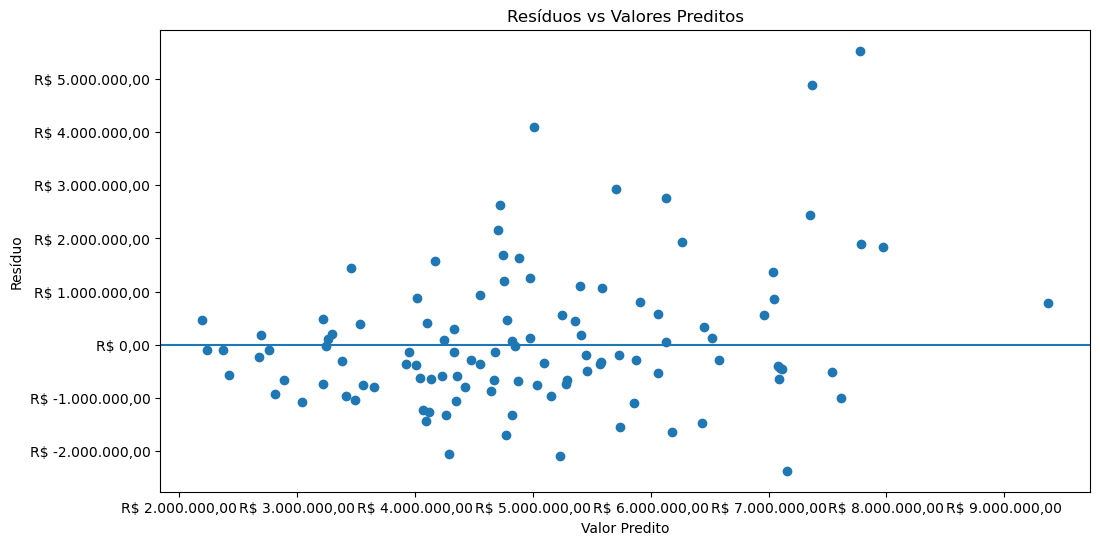

In [26]:
residuos_svr = y_teste - predictions_svr

plt.figure(figsize=(12,6))
plt.scatter(predictions_svr, residuos_svr)
plt.axhline(0)

plt.xlabel('Valor Predito')
plt.ylabel('Resíduo')

ax = plt.gca()
ax.xaxis.set_major_formatter(FuncFormatter(real_formatter))
ax.yaxis.set_major_formatter(FuncFormatter(real_formatter))

plt.title('Resíduos vs Valores Preditos')
plt.show()

### Comparação dos resultados

In [27]:
r2_results = [r2_gb, r2_knn, r2_svr] # coeficientes de determinação
names_models = ['Gradient Boosting', 'KNN', 'SVR Linear'] # modelos

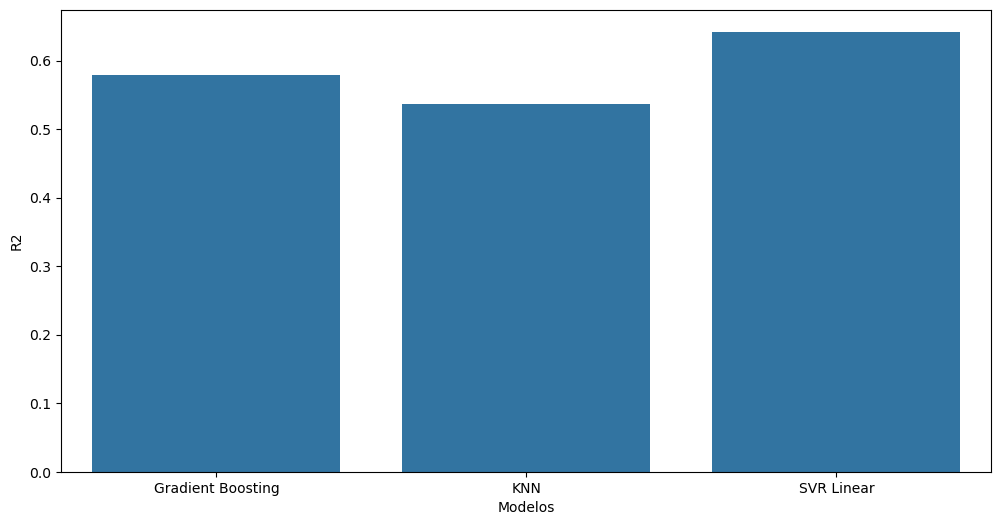

In [28]:
plt.figure(figsize=(12,6))
sns.barplot(x=names_models, y=r2_results)
plt.xlabel('Modelos')
plt.ylabel('R2')
plt.show()

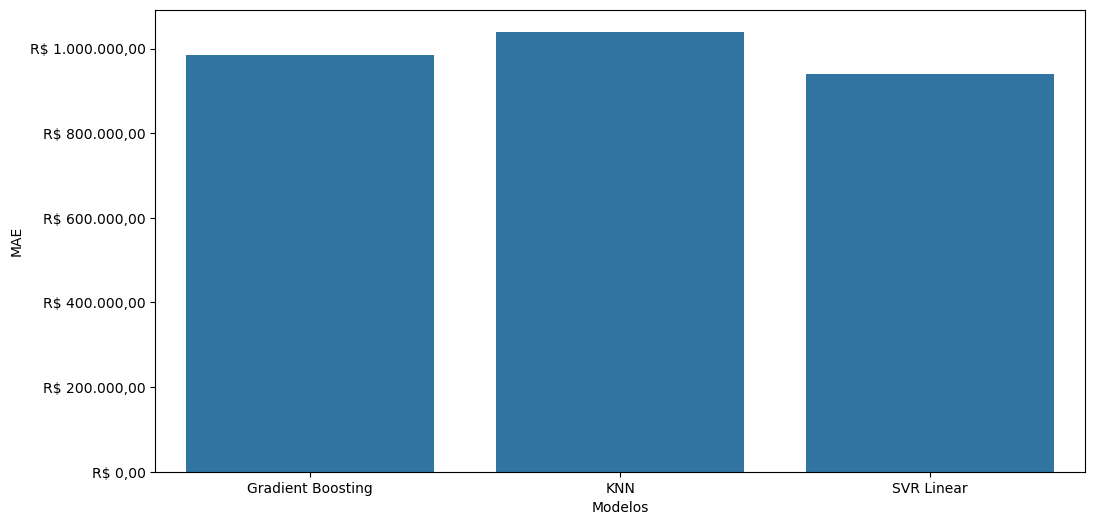

In [29]:
mae_results = [mae_gb, mae_knn, mae_svr] # erro médio absoluto
plt.figure(figsize=(12,6))
sns.barplot(x=names_models, y=mae_results)
plt.xlabel('Modelos')
plt.ylabel('MAE')
ax = plt.gca()
ax.yaxis.set_major_formatter(FuncFormatter(real_formatter))
plt.show()

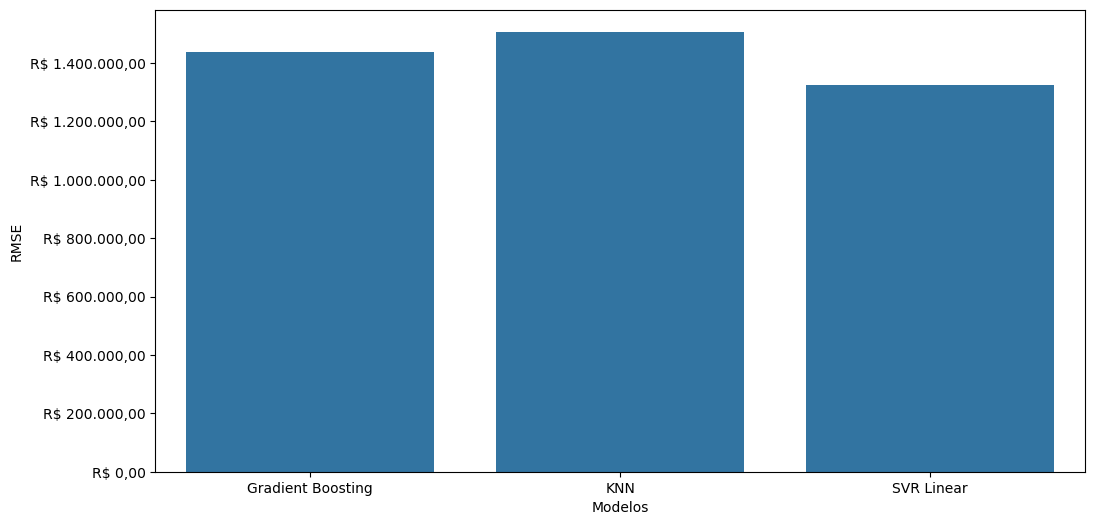

In [30]:
rmse_results = [rmse_gb, rmse_knn, rmse_svr] # raiz do erro médio ao quadrado
plt.figure(figsize=(12,6))
sns.barplot(x=names_models, y=rmse_results)
plt.xlabel('Modelos')
plt.ylabel('RMSE')
ax = plt.gca()
ax.yaxis.set_major_formatter(FuncFormatter(real_formatter))
plt.show()